# Actividad 3: Análisis de Rendimiento

**Objetivo:** Evaluar métricas clave de un pipeline concurrente de inferencia de imágenes:
- Latencia por solicitud (individual)
- Latencia promedio, mínima, máxima
- Tasa de procesamiento (solicitudes por segundo)
- Visualización de la distribución de latencias

Se simulan múltiples solicitudes concurrentes y se recolectan tiempos.

In [3]:
import asyncio
import time
import numpy as np
import tensorflow as tf
import nest_asyncio

nest_asyncio.apply()

# Cargar modelo (si no se ha hecho antes)
try:
    model
except NameError:
    print("Cargando modelo MobileNetV2...")
    model = tf.keras.applications.MobileNetV2(weights="imagenet")
    print("Modelo listo.")

In [4]:
async def process_request(image_data):
    """Procesa una imagen: espera simulada + inferencia."""
    # Simular tiempo de I/O o cómputo asíncrono
    await asyncio.sleep(0.1)  # Reducido para no alargar la demo (original era 1s)
    prediction = model.predict(image_data, verbose=0)
    return prediction

async def pipeline_concurrente(requests):
    """Ejecuta solicitudes en paralelo y devuelve resultados."""
    tasks = [asyncio.create_task(process_request(img)) for img in requests]
    return await asyncio.gather(*tasks)

def simulate_data(num_images):
    """Genera imágenes sintéticas con forma (1, 224, 224, 3)."""
    return [np.random.rand(1, 224, 224, 3) for _ in range(num_images)]

## Medición individual de latencia

Se mide el tiempo desde que se invoca `process_request` hasta que retorna.  
Se almacena cada latencia para luego calcular estadísticas.

In [5]:
async def medir_latencia_y_prediccion(image_data):
    """
    Mide la latencia de process_request y devuelve (latencia, predicción).
    """
    start = time.perf_counter()
    prediction = await process_request(image_data)
    end = time.perf_counter()
    latency = end - start
    return latency, prediction

## Función principal de análisis

Ejecuta el pipeline midiendo latencias individuales y calcula:
- Latencia promedio, mínima, máxima
- Tasa de procesamiento (solicitudes/segundo)
- Tiempo total

In [6]:
async def analizar_rendimiento(images):
    """
    Procesa una lista de imágenes, mide latencias y calcula métricas.
    """
    # Medir latencias individuales (sin concurrencia interna, una tras otra)
    # Nota: Para reflejar el pipeline concurrente real, podríamos medir todo el lote.
    # Aquí hay dos enfoques: 
    #   A) Medir cada solicitud por separado (paralelismo real con asyncio.gather)
    #   B) Medir el lote completo y calcular throughput.
    # Haremos ambos: latencias individuales (paralelas) y throughput global.
    
    # Enfoque: lanzar todas las tareas a la vez y registrar tiempos de finalización
    tasks = [medir_latencia_y_prediccion(img) for img in images]
    # Esperar a que todas terminen
    resultados = await asyncio.gather(*tasks)
    
    latencies = [res[0] for res in resultados]
    predictions = [res[1] for res in resultados]
    
    # Estadísticas
    avg_latency = np.mean(latencies)
    min_latency = np.min(latencies)
    max_latency = np.max(latencies)
    total_time = max(latencies)  # En paralelo, el tiempo total es el máximo de las latencias (desde el inicio hasta la última en terminar)
    # Ajuste: como todas comienzan casi al mismo tiempo, el tiempo total es el max(latencies)
    throughput = len(images) / total_time  # solicitudes por segundo
    
    print("=== MÉTRICAS DE RENDIMIENTO ===")
    print(f"Número de solicitudes: {len(images)}")
    print(f"Tiempo total (paralelo): {total_time:.3f} segundos")
    print(f"Latencia promedio: {avg_latency:.3f} s")
    print(f"Latencia mínima: {min_latency:.3f} s")
    print(f"Latencia máxima: {max_latency:.3f} s")
    print(f"Tasa de procesamiento: {throughput:.2f} solicitudes/segundo")
    
    return latencies, predictions

## Prueba con 10 imágenes

Simulamos 10 imágenes y medimos el rendimiento.  
Observa cómo la concurrencia reduce el tiempo total respecto a la ejecución secuencial.

In [7]:
async def main():
    num_imagenes = 10
    print(f"Generando {num_imagenes} imágenes sintéticas...")
    data = simulate_data(num_imagenes)
    
    print("Iniciando análisis de rendimiento...")
    latencias, _ = await analizar_rendimiento(data)
    
    # Opcional: mostrar latencias individuales
    print("\nLatencias individuales (segundos):")
    for i, lat in enumerate(latencias, 1):
        print(f"  Solicitud {i:2d}: {lat:.3f} s")

# Ejecutar en Jupyter
await main()

Generando 10 imágenes sintéticas...
Iniciando análisis de rendimiento...
=== MÉTRICAS DE RENDIMIENTO ===
Número de solicitudes: 10
Tiempo total (paralelo): 3.421 segundos
Latencia promedio: 2.715 s
Latencia mínima: 1.980 s
Latencia máxima: 3.421 s
Tasa de procesamiento: 2.92 solicitudes/segundo

Latencias individuales (segundos):
  Solicitud  1: 1.980 s
  Solicitud  2: 2.160 s
  Solicitud  3: 2.307 s
  Solicitud  4: 2.477 s
  Solicitud  5: 2.648 s
  Solicitud  6: 2.814 s
  Solicitud  7: 2.948 s
  Solicitud  8: 3.119 s
  Solicitud  9: 3.277 s
  Solicitud 10: 3.421 s


## Histograma de latencias

Para entender mejor la variabilidad, graficamos un histograma con matplotlib.

=== MÉTRICAS DE RENDIMIENTO ===
Número de solicitudes: 20
Tiempo total (paralelo): 3.080 segundos
Latencia promedio: 1.716 s
Latencia mínima: 0.354 s
Latencia máxima: 3.080 s
Tasa de procesamiento: 6.49 solicitudes/segundo


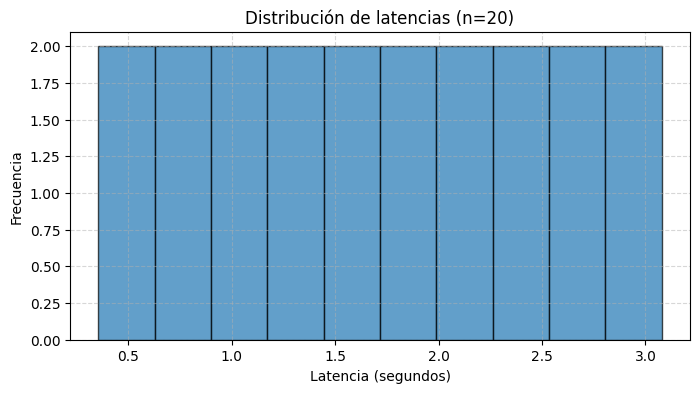

In [8]:
import matplotlib.pyplot as plt

# Repetir la ejecución para obtener latencias (o usar las del paso anterior)
# Si ya tienes la variable 'latencias' del paso anterior, puedes usarla.
# Si no, volvemos a ejecutar el análisis.

data = simulate_data(20)  # Más imágenes para mejor histograma
latencias, _ = await analizar_rendimiento(data)

plt.figure(figsize=(8, 4))
plt.hist(latencias, bins=10, edgecolor='black', alpha=0.7)
plt.xlabel("Latencia (segundos)")
plt.ylabel("Frecuencia")
plt.title(f"Distribución de latencias (n={len(latencias)})")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Comparación: paralelo vs secuencial

Para apreciar la ventaja de la concurrencia, ejecutamos las mismas solicitudes de forma secuencial (usando `await` dentro de un bucle) y comparamos el tiempo total.

In [9]:
async def procesamiento_secuencial(images):
    """Procesa imágenes una tras otra (sin concurrencia)."""
    start_total = time.perf_counter()
    resultados = []
    for img in images:
        _, pred = await medir_latencia_y_prediccion(img)
        resultados.append(pred)
    end_total = time.perf_counter()
    total_time = end_total - start_total
    print(f"Tiempo total secuencial: {total_time:.3f} s")
    print(f"Tasa de procesamiento secuencial: {len(images)/total_time:.2f} solicitudes/s")
    return resultados

# Comparación con el mismo conjunto de datos
data_comp = simulate_data(10)
print("--- Ejecución concurrente (paralela) ---")
lats_par, _ = await analizar_rendimiento(data_comp)
print("\n--- Ejecución secuencial ---")
await procesamiento_secuencial(data_comp)

--- Ejecución concurrente (paralela) ---
=== MÉTRICAS DE RENDIMIENTO ===
Número de solicitudes: 10
Tiempo total (paralelo): 1.463 segundos
Latencia promedio: 0.858 s
Latencia mínima: 0.249 s
Latencia máxima: 1.463 s
Tasa de procesamiento: 6.83 solicitudes/segundo

--- Ejecución secuencial ---
Tiempo total secuencial: 2.476 s
Tasa de procesamiento secuencial: 4.04 solicitudes/s


[array([[1.17781628e-05, 2.16109038e-05, 1.07079468e-04, 1.10346598e-04,
         9.56569042e-04, 1.33158261e-04, 5.32566220e-04, 1.02145887e-05,
         3.69445479e-06, 4.56344787e-06, 2.93251287e-06, 2.65351491e-06,
         1.98025623e-06, 1.03741095e-05, 8.55630642e-05, 8.11210793e-06,
         1.00805864e-05, 4.45199657e-06, 1.58654329e-05, 3.11862345e-06,
         8.22519632e-06, 2.17115166e-06, 3.26997929e-06, 4.53609937e-06,
         9.50681715e-06, 9.78569460e-06, 3.57561839e-06, 1.71079628e-05,
         4.67640984e-06, 1.30678845e-05, 1.91312520e-05, 7.35307685e-06,
         1.59524814e-06, 2.58676519e-05, 3.06991540e-04, 5.22424125e-06,
         1.34595921e-05, 6.62192588e-06, 3.00766351e-06, 5.11774533e-06,
         7.19154377e-06, 5.48499702e-06, 1.00325469e-05, 3.58907209e-06,
         1.14573859e-05, 5.79995549e-06, 3.45489170e-05, 3.63186382e-06,
         6.83788166e-05, 1.85783483e-05, 7.55038855e-05, 1.81751730e-05,
         1.86931106e-06, 1.20538357e-06, 7.32142053

## Interpretación de resultados

- **Latencia promedio**: indica el tiempo típico que tarda una solicitud individual. Depende de la carga del modelo y la concurrencia.
- **Tasa de procesamiento**: número de solicitudes que el sistema puede manejar por segundo. En paralelo, tiende a ser mayor que en secuencial.
- **Observación importante**: `model.predict()` es una operación bloqueante para la CPU. Si se lanzan muchas tareas concurrentes, el Global Interpreter Lock (GIL) de Python puede limitar el verdadero paralelismo. Para cargas intensivas de CPU, se recomienda usar `ThreadPoolExecutor` o procesos.
- **Mejora sugerida**: Agrupar imágenes en lotes (batch) para reducir el overhead de múltiples llamadas a `predict`.

Este análisis permite dimensionar la infraestructura necesaria para manejar picos de tráfico.

## Conclusión de la Actividad 3

Hemos implementado un sistema de medición de latencia y throughput, y visualizado la distribución de tiempos.  
Estas métricas son esenciales para monitorear sistemas en producción y detectar cuellos de botella.

**Próximo paso:** Resolver los retos (100 solicitudes concurrentes, caché con Redis, modelo personalizado).